# Create Quantized Latent Datasets from an Image Dataset

Instead of having to decompress pixel-based images and autoencode them regularly; it's often more efficient to work on a precomputed quantized latent representation of the images instead.

In [2]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.misc.image_helpers as ih
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
import hierarchical_binary_quantization.misc.dataset_helpers as dh
import hierarchical_binary_quantization.example_narrow_reciptive_field_autoencoder as enrfa
import torchvision as tv

In [38]:
print("convenient sizes")
[(x,"grid:",x*4,"img:",x*8*4) for x in range(1,17)]

convenient sizes


[(1, 'grid:', 4, 'img:', 32),
 (2, 'grid:', 8, 'img:', 64),
 (3, 'grid:', 12, 'img:', 96),
 (4, 'grid:', 16, 'img:', 128),
 (5, 'grid:', 20, 'img:', 160),
 (6, 'grid:', 24, 'img:', 192),
 (7, 'grid:', 28, 'img:', 224),
 (8, 'grid:', 32, 'img:', 256),
 (9, 'grid:', 36, 'img:', 288),
 (10, 'grid:', 40, 'img:', 320),
 (11, 'grid:', 44, 'img:', 352),
 (12, 'grid:', 48, 'img:', 384),
 (13, 'grid:', 52, 'img:', 416),
 (14, 'grid:', 56, 'img:', 448),
 (15, 'grid:', 60, 'img:', 480),
 (16, 'grid:', 64, 'img:', 512)]

In [ ]:
dataset_name = 'fantasy'
width,height=224,320

## Create an autoencoder to generate the latent embeddings.

In [24]:
autoencoder_cp = 'checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth'
autoencoder = ch.create_from_checkpoint(enrfa.LocalQuantizingAutoencoder,autoencoder_cp)
autoencoder.eval()
autoencoder.config

🔄 Loading checkpoint from checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth with {'in_channels': 3, 'stem_dim': 64, 'stem_blocks': 1, 'patch_size': 8, 'body_dim': 256, 'body': ('res', 'attn', 'res'), 'attn_block': 4, 'attn_halo': 1, 'attn_heads': 4, 'attn_rope_base': 150, 'latent_dim': 32, 'quant_dim': 16, 'n_rounds': 4, 'refine_blocks': 2, 'depatchify_overlap': 1, 'use_mae_aux': True, 'mae_mask_ratio': 0.5, 'mae_heads': 2, 'mae_depth': 2}


LocalAutoencoderConfig(in_channels=3, stem_dim=64, stem_blocks=1, patch_size=8, body_dim=256, body=('res', 'attn', 'res'), attn_block=4, attn_halo=1, attn_heads=4, attn_rope_base=150, latent_dim=32, quant_dim=16, n_rounds=4, refine_blocks=2, depatchify_overlap=1, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=2, mae_depth=2)

## Open an image dataset, and define a transform to match the autoencoder's preferred input

In this case rgb values ranging [-1,1], in the shape [C, H, W].

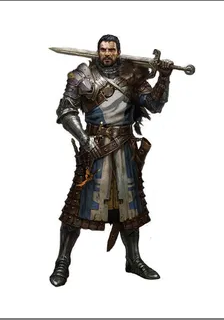

In [31]:
transform = tv.transforms.Compose([
    dh.PadToRectangle(width=width,height=height,background_color=(128,128,128)),
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
bds = dh.BlobDataset(f"data/dbs/{dataset_name}_{width}x{height}.sqlite3","r")
imgds = dh.ImageDataset(bds, transform)
ih.tensor_to_pil(imgds[-1][1])

## Apply the autoencoder to convert the dataset

In [26]:
dh.image_dataset_to_quantized_latent_dataset(autoencoder, width, height, dataset_name='fantasy', device='cuda')

 10%|█         | 1165/11178 [00:16<02:17, 72.56it/s]


KeyboardInterrupt: 

## Verify that we can load the quantized latent embeddings and decode them

In [ ]:
width

In [ ]:
import IPython.display as ipd
from torch.utils.data import Dataset, DataLoader

def get_latent_dataset_and_dataloader(dataset_name,width=width,height=height,batch_size=8, shuffle=False):
    bds = dh.BlobDataset(f"data/dbs/quantized_latents_for_{dataset_name}_{width}x{height}.sqlite3")
    lds = dh.QuantizedLatentDataset(bds)
    ldl = DataLoader(lds,shuffle=shuffle,batch_size=batch_size)
    return lds,ldl

autoencoder.cpu()
def smoke_test_data_loader_and_autoencoder(dataset):
    lds,ldl = get_latent_dataset_and_dataloader(dataset,shuffle=True)
    id_batch, ld_batch, metadata_batch = next(iter(ldl))
    print(ld_batch.shape)
    ipd.display(ih.tensor_to_pil(autoencoder.decode(autoencoder.post_quant(ld_batch))[0]))

smoke_test_data_loader_and_autoencoder(dataset='fantasy')
